
> ## ✅ 결론 — 이상치 처리: **baseline 유지 (제거 안 함)**
>
> | 실험 | 처리 | XGB Val R² |
> |---|---|---|
> | **baseline** | 처리 안 함 | **0.0824** |
> | clip_speed | 구속 클리핑 | 0.0812 |
> | remove_y | Y 이상치 328행 제거 | 0.0782 |
> | clip+remove | 둘 다 | 0.0772 |
>
> - 이상치 제거·클리핑 모두 **오히려 R² 하락**.
> - Y 이상치(극단적 whiff%)도 실제 신호 → 제거 시 정보 손실.
> - **→ baseline(원본 그대로) 유지.**


# 09. 이상치 처리 실험
- 07_delta_experiment 확정 (with delta, pitch15) 기반
- Y EDA 결과 반영: whiff% 극단값 경기 제거 여부 비교

| 실험 | 내용 |
|---|---|
| E4-1 | 없음 (베이스라인) |
| E4-2 | X 구속 feature 상하 1% clip |
| E4-3 | Y 극단값 제거 (whiff% < 0.05 or > 0.60) |
| E4-4 | E4-2 + E4-3 조합 |

In [1]:
import os, sys

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    if not os.path.exists('/content/drive/MyDrive'):
        from google.colab import drive
        drive.mount('/content/drive')
    DRIVE  = '/content/drive/MyDrive/투수 컨디션 예측 ML'
else:
    DRIVE  = r'c:\Users\suyou\OneDrive\Desktop\ASAC\PROJECT\투수 컨디션 예측'

NB_DIR = os.path.join(DRIVE, '3_modeling')
sys.path.insert(0, NB_DIR)   # if/else 밖으로 이동 — 항상 실행

FEATURE_PATH = os.path.join(DRIVE, '0_data', '4_features', 'features_pitch15.parquet')
OUTPUT_DIR   = os.path.join(DRIVE, '4_output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'환경: {"코랩" if IN_COLAB else "로컬"}')
print(f'NB_DIR: {NB_DIR}')
print(f'outlier_handler.py 존재: {os.path.exists(os.path.join(NB_DIR, "outlier_handler.py"))}')
print(f'데이터: {FEATURE_PATH}')

Mounted at /content/drive
환경: 코랩
NB_DIR: /content/drive/MyDrive/투수 컨디션 예측 ML/3_modeling
outlier_handler.py 존재: True
데이터: /content/drive/MyDrive/투수 컨디션 예측 ML/0_data/4_features/features_pitch15.parquet


In [2]:
try:
    import xgboost, catboost, lightgbm
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'xgboost', 'catboost', 'lightgbm', '-q'])

import importlib
import outlier_handler as oh
importlib.reload(oh)

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('모듈 로드 완료')

모듈 로드 완료


## 1. 전체 실험 실행

In [3]:
summary = oh.run_all(FEATURE_PATH)
summary

[E4-1 baseline] 실행 중...
  제거 샘플: 0개
  XGB Val RMSE=0.0851  R²=0.0824
  CB  Val RMSE=0.0849  R²=0.0861
  LGB Val RMSE=0.0850  R²=0.0835

[E4-2 clip_speed] 실행 중...
  제거 샘플: 0개
  XGB Val RMSE=0.0851  R²=0.0812
  CB  Val RMSE=0.0848  R²=0.0874
  LGB Val RMSE=0.0851  R²=0.0816

[E4-3 remove_y] 실행 중...
  제거 샘플: 328개
  XGB Val RMSE=0.0821  R²=0.0782
  CB  Val RMSE=0.0818  R²=0.0856
  LGB Val RMSE=0.0821  R²=0.0798

[E4-4 clip+remove] 실행 중...
  제거 샘플: 328개
  XGB Val RMSE=0.0822  R²=0.0772
  CB  Val RMSE=0.0819  R²=0.0843
  LGB Val RMSE=0.0821  R²=0.0781



,do_clip_speed,do_remove_y,n_removed,n_train,n_val,n_test,n_features,xgb_train_rmse,xgb_train_r2,xgb_val_rmse,...,cb_val_r2,cb_test_rmse,cb_test_r2,lgb_train_rmse,lgb_train_r2,lgb_val_rmse,lgb_val_r2,lgb_test_rmse,lgb_test_r2,name
0,False,False,0,13871,4668,4686,59,0.079798,0.221986,0.085073,...,0.086136,0.088825,0.026655,0.076437,0.286141,0.085023,0.083483,0.088772,0.027816,E4-1 baseline
1,True,False,0,13871,4668,4686,59,0.078793,0.241462,0.085129,...,0.087442,0.088600,0.031576,0.078061,0.255493,0.085109,0.081612,0.088151,0.041361,E4-2 clip_speed
2,False,True,328,13695,4591,4611,59,0.075740,0.256632,0.082136,...,0.085554,0.085374,0.034961,0.075166,0.267860,0.082062,0.079833,0.085558,0.030794,E4-3 remove_y
3,True,True,328,13695,4591,4611,59,0.075614,0.259104,0.082182,...,0.084293,0.085221,0.038416,0.075203,0.267146,0.082140,0.078084,0.085473,0.032716,E4-4 clip+remove


## 2. 결과 비교 테이블

In [4]:
cols = ['name', 'n_removed', 'n_train', 'n_val',
        'xgb_val_rmse', 'xgb_val_r2',
        'cb_val_rmse',  'cb_val_r2',
        'lgb_val_rmse', 'lgb_val_r2']
print(summary[cols].round(4).to_string(index=False))

            name  n_removed  n_train  n_val  xgb_val_rmse  xgb_val_r2  cb_val_rmse  cb_val_r2  lgb_val_rmse  lgb_val_r2
   E4-1 baseline          0    13871   4668        0.0851      0.0824       0.0849     0.0861        0.0850      0.0835
 E4-2 clip_speed          0    13871   4668        0.0851      0.0812       0.0848     0.0874        0.0851      0.0816
   E4-3 remove_y        328    13695   4591        0.0821      0.0782       0.0818     0.0856        0.0821      0.0798
E4-4 clip+remove        328    13695   4591        0.0822      0.0772       0.0819     0.0843        0.0821      0.0781


## 3. Val R² 시각화

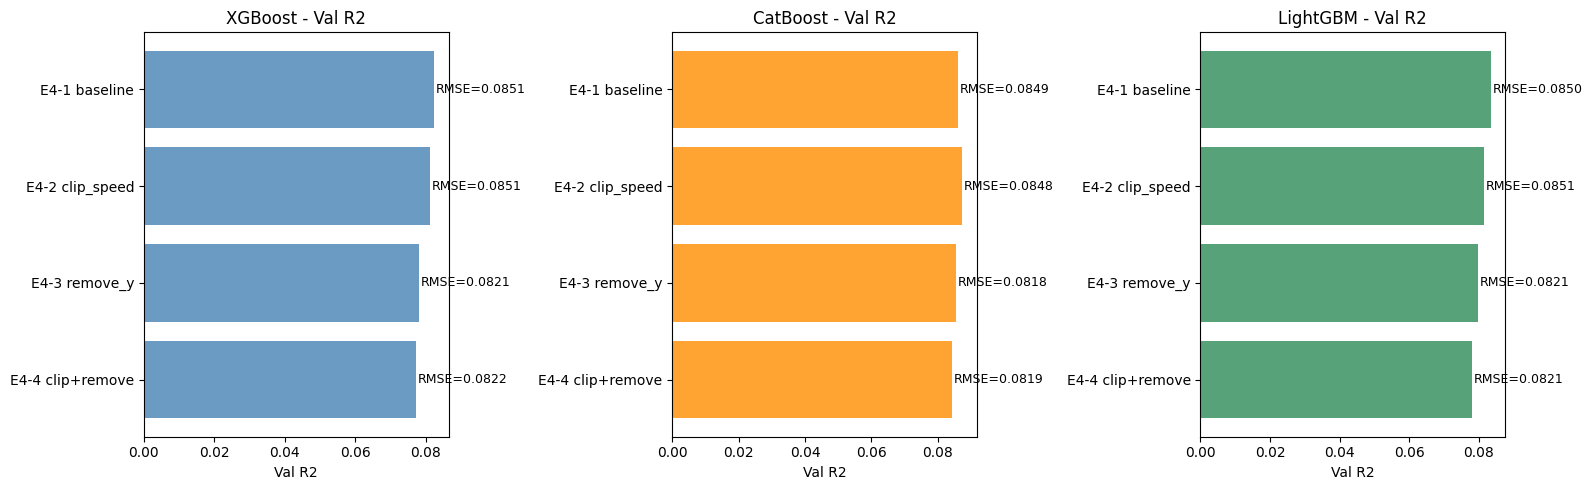

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = [('xgb', 'XGBoost', 'steelblue'),
          ('cb',  'CatBoost', 'darkorange'),
          ('lgb', 'LightGBM', 'seagreen')]

for ax, (key, label, color) in zip(axes, models):
    r2_col   = f'{key}_val_r2'
    rmse_col = f'{key}_val_rmse'
    bars = ax.barh(summary['name'], summary[r2_col], color=color, alpha=0.8)
    ax.set_xlabel('Val R2')
    ax.set_title(f'{label} - Val R2')
    ax.invert_yaxis()
    for bar, rmse in zip(bars, summary[rmse_col]):
        ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                f'RMSE={rmse:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4. 결론 및 확정

In [6]:
best = summary.loc[summary['xgb_val_r2'].idxmax()]
print(f'XGB 기준 최적: {best["name"]}')
print(f'  Val RMSE={best["xgb_val_rmse"]:.4f}  R2={best["xgb_val_r2"]:.4f}')
print(f'  제거 샘플: {best["n_removed"]}개')

XGB 기준 최적: E4-1 baseline
  Val RMSE=0.0851  R2=0.0824
  제거 샘플: 0개


In [7]:
out_path = os.path.join(OUTPUT_DIR, 'outlier_experiment_results.csv')
summary[cols].to_csv(out_path, index=False)
print(f'저장 완료 -> {out_path}')

저장 완료 -> /content/drive/MyDrive/투수 컨디션 예측 ML/4_output/outlier_experiment_results.csv
